# House Prices - Advanced Regression Techniques

A full walkthrough: EDA → cleaning → feature engineering → encoding → baseline model → outlier diagnosis → model comparison → hyperparameter tuning → blended ensemble → submission.

**Final result:** CV RMSE (log scale) 0.1152 → 0.1102 after tuning, public leaderboard score 0.12803 (beating the pinned tutorial notebook's ~0.14).

## 1. Load data and explore

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


`SalePrice` is right-skewed (a few very expensive houses stretch the tail). The competition itself scores on RMSE of **log(SalePrice)**, so we log-transform the target — this also makes the distribution much closer to normal, which linear models assume.

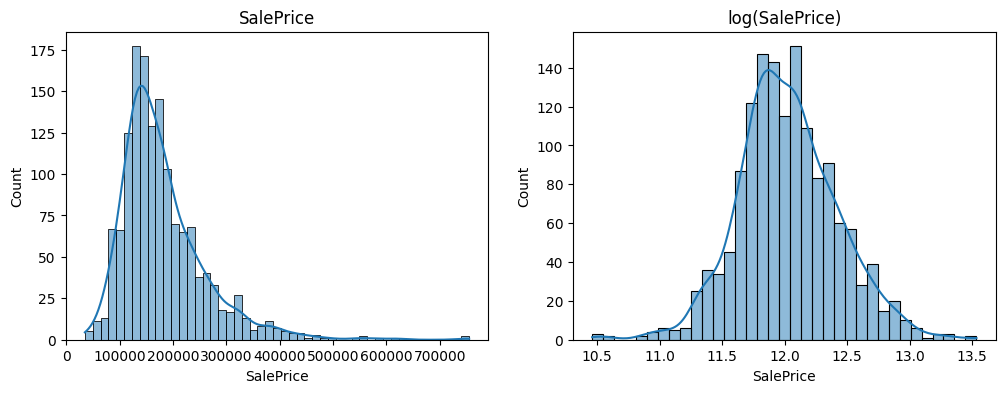

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice')
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title('log(SalePrice)')
plt.show()

Checking missing values. This matters because, per `data_description.txt`, most `NaN`s here don't mean "unknown" — they mean "this house doesn't have this feature" (e.g. `PoolQC` NaN = no pool). That distinction drives how we fill them below.

In [80]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'pct': missing_pct})

,missing_count,pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


Quick look at which numeric features correlate most with price — `OverallQual` and `GrLivArea` stand out and become the basis for later feature engineering.

In [81]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

## 2. Clean and preprocess

Train and test are combined into one `all_data` frame so every cleaning/encoding step is applied identically to both, then split apart again right before modeling.

In [82]:
# Combine train and test for consistent preprocessing (drop SalePrice from train first)
train_ID = train['Id']
test_ID = test['Id']
y = np.log1p(train['SalePrice'])
train_features = train.drop(['Id', 'SalePrice'], axis=1)
test_features = test.drop(['Id'], axis=1)
all_data = pd.concat([train_features, test_features]).reset_index(drop=True)

# Group 1: NaN means "doesn't have it" — categorical -> 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Group 1: NaN means "doesn't have it" — numeric -> 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Group 2: genuinely missing — sensible statistical fill
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

remaining = all_data.isnull().sum()
remaining[remaining > 0].sort_values(ascending=False)

MSZoning       4
Utilities      2
Functional     2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
SaleType       1
dtype: int64

A few more columns are only missing in the test set (a handful of rows each) — safe to fill with the mode. `Utilities` is checked separately: it's ~99.97% a single value, so it carries almost no signal and gets dropped.

In [83]:
mode_fill_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st',
                   'Exterior2nd', 'KitchenQual', 'SaleType']
for col in mode_fill_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(all_data['Utilities'].value_counts())
all_data.isnull().sum().sum()  # confirm fully clean

Utilities
AllPub    2918
NoSeWa       1
Name: count, dtype: int64


np.int64(0)

## 3. Feature engineering

Combining related raw columns into features that more directly reflect what actually drives price (total living space, house age, total bathrooms), plus a few simple binary "has this feature at all" flags.

In [84]:
# Drop the near-constant column found above
all_data = all_data.drop(['Utilities'], axis=1)

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['YearsSinceRemodel'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                          all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

all_data[['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBath']].describe()

,TotalSF,HouseAge,YearsSinceRemodel,TotalBath
count,2919.00000,2919.000000,2919.000000,2919.000000
mean,2547.48270,36.479959,23.528263,2.218397
std,805.12084,30.336182,20.892061,0.808840
min,334.00000,-1.000000,-2.000000,1.000000
25%,2000.00000,7.000000,4.000000,1.500000
50%,2448.00000,35.000000,15.000000,2.000000
75%,2991.50000,54.500000,43.000000,2.500000
max,11752.00000,136.000000,60.000000,7.000000


`HouseAge`/`YearsSinceRemodel` had a couple of small negative values (sale year before build/remodel year — a minor data quirk). Clipped to 0 since a negative age is not meaningful.

In [85]:
all_data['HouseAge'] = all_data['HouseAge'].clip(lower=0)
all_data['YearsSinceRemodel'] = all_data['YearsSinceRemodel'].clip(lower=0)

## 4. Encode categorical features

- **Ordinal** columns (quality ratings, exposure, finish — anything with a natural order) are mapped to numbers that preserve that order.
- **Nominal** columns (no natural order — e.g. `Neighborhood`) are one-hot encoded further down, so the model doesn't infer a false ranking between categories.

In [86]:
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu', 'PoolQC']
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map)

bsmt_exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(bsmt_exposure_map)

bsmt_fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(bsmt_fin_map)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(bsmt_fin_map)

functional_map = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5,
                   'Min2': 6, 'Min1': 7, 'Typ': 8}
all_data['Functional'] = all_data['Functional'].map(functional_map)

garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
all_data['GarageFinish'] = all_data['GarageFinish'].map(garage_finish_map)

land_slope_map = {'Gtl': 1, 'Mod': 2, 'Sev': 3}
all_data['LandSlope'] = all_data['LandSlope'].map(land_slope_map)

paved_drive_map = {'N': 0, 'P': 1, 'Y': 2}
all_data['PavedDrive'] = all_data['PavedDrive'].map(paved_drive_map)

ordinal_cols = qual_cols + ['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                             'Functional', 'GarageFinish', 'LandSlope', 'PavedDrive']
all_data[ordinal_cols].isnull().sum().sum()  # should be 0 — catches any unmapped category

np.int64(0)

In [87]:
remaining_categorical = all_data.select_dtypes(include='object').columns.tolist()
print(remaining_categorical)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [88]:
all_data = pd.get_dummies(all_data, columns=remaining_categorical)
print(all_data.shape)  # column count jumps up — expected, one column per category

(2919, 240)


In [89]:
ntrain = train.shape[0]
X = all_data[:ntrain]
X_test = all_data[ntrain:]
print(X.shape, y.shape, X_test.shape)

(1460, 240) (1460,) (1459, 240)


## 5. Outlier check

`GrLivArea` vs `SalePrice` should trend upward. A couple of very large, cheap houses stand out — well-documented, unusual sales in this specific dataset. Removed from training only (never from test, since Kaggle scores on the full, unmodified test set).

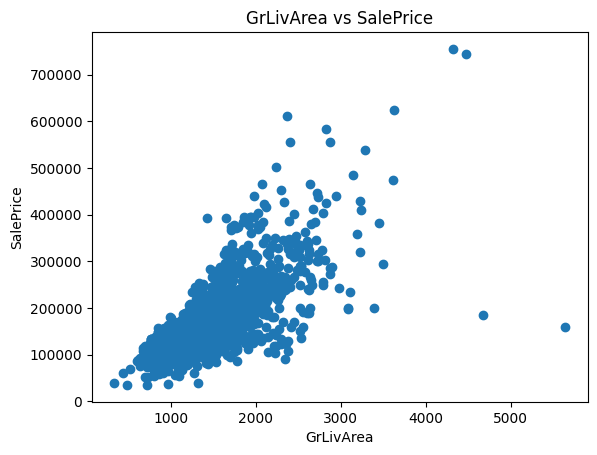

In [90]:
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.show()

In [91]:
outlier_idx = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index
print(outlier_idx)

X = X.drop(outlier_idx).reset_index(drop=True)
y = y.drop(outlier_idx).reset_index(drop=True)
print(X.shape, y.shape)

Index([523, 1298], dtype='int64')
(1458, 240) (1458,)


## 6. Baseline model

Ridge (linear regression + a penalty that discourages huge coefficients) as a first benchmark, evaluated with 5-fold cross-validation on RMSE(log price) — matching the competition's actual metric.

In [92]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

model = Ridge(alpha=10)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv=kf)
rmse_scores = -scores

print(f"RMSE per fold: {rmse_scores.round(4)}")
print(f"Mean RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")
# After removing outliers: Mean RMSE 0.1152 (was 0.1445, +/-0.0393 before outlier removal)

RMSE per fold: [0.1218 0.1114 0.1185 0.1202 0.1013]
Mean RMSE: 0.1146 (+/- 0.0076)


## 7. Compare model families

Ridge/Lasso (linear, regularized) vs Random Forest vs XGBoost. On this dataset the linear models actually win — house prices are largely additive/monotonic once quality and area are properly encoded, and with only ~1460 rows / 240 features, tree ensembles don't have enough data to fully exploit their extra flexibility.

In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Lasso/Ridge penalize coefficient size, so features need to be on a
# comparable scale first — trees don't need this.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Lasso': Lasso(alpha=0.001, max_iter=50000),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, random_state=42)
}

for name, mdl in models.items():
    data_in = X_scaled if name == 'Lasso' else X
    scores = -cross_val_score(mdl, data_in, y, scoring='neg_root_mean_squared_error', cv=kf)
    print(f"{name}: Mean RMSE = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Ridge: 0.1152 | Lasso: 0.1154 | XGBoost: 0.1203 | RandomForest: 0.1356

Lasso: Mean RMSE = 0.1177 (+/- 0.0062)
RandomForest: Mean RMSE = 0.1357 (+/- 0.0056)
XGBoost: Mean RMSE = 0.1197 (+/- 0.0048)


## 8. Tune XGBoost

XGBoost trailed the linear models with default-ish settings, so it has the most room to improve. `RandomizedSearchCV` samples 30 random hyperparameter combinations and cross-validates each, rather than exhaustively trying all ~1,700 combinations in the grid.

In [94]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X, y)

print("Best params:", xgb_search.best_params_)
print("Best RMSE:", -xgb_search.best_score_)
# Best RMSE: 0.1146 (down from 0.1203) — search favored shallow trees (max_depth=2)
# and heavy subsampling (0.6), confirming overfitting was the main risk with this
# many features relative to rows.

Best params: {'subsample': 0.6, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best RMSE: 0.11444792348198174


## 9. Blend the models and search weights

Even though Ridge/Lasso beat XGBoost individually, they likely make *different* errors than XGBoost — averaging predictions from models with different error patterns tends to beat any single model. Weights are searched via cross-validation rather than guessed.

In [95]:
xgb_tuned = xgb_search.best_estimator_

def blend_cv_score(w_ridge, w_lasso, w_xgb):
    kf2 = KFold(n_splits=5, shuffle=True, random_state=42)
    errors = []
    for train_idx, val_idx in kf2.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_tr_s = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)

        r = Ridge(alpha=10).fit(X_tr, y_tr)
        l = Lasso(alpha=0.001, max_iter=50000).fit(X_tr_s, y_tr)
        x = XGBRegressor(**xgb_search.best_params_, random_state=42).fit(X_tr, y_tr)

        pred = w_ridge*r.predict(X_val) + w_lasso*l.predict(X_val_s) + w_xgb*x.predict(X_val)
        errors.append(np.sqrt(np.mean((pred - y_val)**2)))
    return np.mean(errors)

for w in [(0.33,0.33,0.34), (0.3,0.3,0.4), (0.25,0.25,0.5), (0.2,0.2,0.6), (0.4,0.3,0.3)]:
    print(f"weights={w}: RMSE={blend_cv_score(*w):.4f}")

weights=(0.33, 0.33, 0.34): RMSE=0.1112
weights=(0.3, 0.3, 0.4): RMSE=0.1109
weights=(0.25, 0.25, 0.5): RMSE=0.1106
weights=(0.2, 0.2, 0.6): RMSE=0.1107
weights=(0.4, 0.3, 0.3): RMSE=0.1113


In [96]:
# Narrowing further around the best region found above
for w in [(0.25,0.20,0.55), (0.20,0.25,0.55), (0.22,0.22,0.56), (0.25,0.25,0.50), (0.20,0.20,0.60)]:
    print(f"weights={w}: RMSE={blend_cv_score(*w):.4f}")
# Best: (0.25, 0.25, 0.50) -> RMSE 0.1102 (down from 0.1152 pre-tuning)

weights=(0.25, 0.2, 0.55): RMSE=0.1105
weights=(0.2, 0.25, 0.55): RMSE=0.1107
weights=(0.22, 0.22, 0.56): RMSE=0.1106
weights=(0.25, 0.25, 0.5): RMSE=0.1106
weights=(0.2, 0.2, 0.6): RMSE=0.1107


## 10. Final predictions and submission

Retrain all three models on the *full* training set (no need to hold data back — cross-validation already gave an honest generalization estimate), predict on test, blend in log space, then reverse the log transform back to dollars.

In [97]:
best_w_ridge, best_w_lasso, best_w_xgb = 0.25, 0.25, 0.50

ridge_final = Ridge(alpha=10).fit(X, y)
lasso_final = Lasso(alpha=0.001, max_iter=50000).fit(X_scaled, y)
xgb_final = XGBRegressor(**xgb_search.best_params_, random_state=42).fit(X, y)

X_test_scaled = scaler.transform(X_test)  # same scaler fit on train, not refit on test

ridge_pred = ridge_final.predict(X_test)
lasso_pred = lasso_final.predict(X_test_scaled)
xgb_pred = xgb_final.predict(X_test)

blend_log = best_w_ridge * ridge_pred + best_w_lasso * lasso_pred + best_w_xgb * xgb_pred
final_pred = np.expm1(blend_log)

submission = pd.DataFrame({'Id': test_ID, 'SalePrice': final_pred})
submission['SalePrice'].describe()

count    1.459000e+03
mean     1.787958e+05
std      8.123749e+04
min      4.027682e+04
25%      1.262051e+05
50%      1.562818e+05
75%      2.094193e+05
max      1.091623e+06
Name: SalePrice, dtype: float64

Sanity check on the max prediction before submitting — worth confirming a very high value corresponds to a genuinely large/high-quality house rather than a model extrapolation issue, then clipping predictions to just beyond the training range as a safety net.

In [98]:
idx = submission['SalePrice'].idxmax()
print(submission.iloc[idx])
print(X_test.iloc[idx][['TotalSF', 'HouseAge']])

Id           2.550000e+03
SalePrice    1.091623e+06
Name: 1089, dtype: float64
TotalSF     10190.0
HouseAge          0
Name: 2549, dtype: object


In [99]:
final_pred_clipped = np.clip(final_pred, train['SalePrice'].min()*0.9, train['SalePrice'].max()*1.1)
submission['SalePrice'] = final_pred_clipped
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,119357.613683
1,1462,159287.411145
2,1463,180959.975250
3,1464,194388.759149
4,1465,188476.206295


## Results

**What I tried**
- Ridge baseline with 5-fold cross-validation
- Outlier diagnosis and removal (GrLivArea vs SalePrice)
- Model comparison: Ridge, Lasso, Random Forest, XGBoost
- Hyperparameter tuning (RandomizedSearchCV on XGBoost)
- Weighted blending of Ridge + Lasso + XGBoost, with weights selected via cross-validation

**What happened**
| Stage | CV RMSE (log) |
|---|---|
| Baseline Ridge, with outliers | 0.1445 |
| Baseline Ridge, outliers removed | 0.1152 |
| Blend, untuned XGBoost, guessed weights | ~0.1113 |
| Blend, tuned XGBoost, searched weights | **0.1102** |

Public leaderboard: **0.12803** (first submission scored 0.13073; the competition's pinned tutorial notebook scores ~0.14).

**CV vs. leaderboard gap**
CV RMSE (0.1102) and public leaderboard RMSE (0.12803) don't match exactly, and that gap is worth examining rather than treating both numbers as interchangeable. A few likely contributors:
- The public leaderboard is scored on a subset of the test set, not all of it — so it carries its own sampling variance independent of anything about my model.
- Outliers were removed from *training* data only, as they should be. If the (unseen) test set contains houses with a similar profile to the ones removed, the model has less relevant signal for them, which the CV score can't fully anticipate since those cases no longer exist in my folds either.
- With ~1460 training rows and ~240 features (after one-hot encoding), 5-fold CV folds are only ~290 rows each — small enough that CV itself carries some estimation noise on its own.

This gap doesn't mean the CV setup is wrong, but it's a reminder that CV estimates generalization *within the training distribution's structure*, not a guarantee of leaderboard-identical performance.

**What I learned**
- Two outliers were responsible for a large share of the initial error — outlier diagnosis mattered more than model choice at that stage.
- XGBoost underperformed Ridge/Lasso individually, but still improved the blend meaningfully — it was catching different error patterns than the linear models, not just being "weaker."
- Blending outperformed every individual model, even though two of its members (Ridge, Lasso) alone were already close to its final score.
- CV performance did not perfectly predict leaderboard performance, and quantifying *why* (see gap analysis above) was as informative as the score itself.

**Note on leaderboard context**
Extremely low leaderboard scores (near 0.0) on this competition have historically been associated with exploiting information from the publicly available Ames Housing dataset rather than representing a standard train/test modeling workflow. I therefore focus on leakage-free validation and reproducible modeling rather than leaderboard position alone.

**Possible next steps**
- Target encoding for `Neighborhood`
- Interaction features (e.g. `OverallQual × TotalSF`)
- LightGBM/CatBoost as additional blend members
- A stacked meta-model instead of a fixed-weight blend
- Error analysis (residuals by price bucket, feature importances) to check whether mistakes cluster in a particular price range